### INSTALLATION

In [ ]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

!wget -q https://archive.apache.org/dist/spark/spark-3.3.2/spark-3.3.2-bin-hadoop3.tgz
!tar xf spark-3.3.2-bin-hadoop3.tgz

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.3.2-bin-hadoop3"

!pip install -q pyspark==3.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 16.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.1 requires pyspark[connect]~=4.0.0, but you have pyspark 3.3.2 which is incompatible.


### RETRIEVING DATA

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
        .master("local[*]")
        .appName("Job")
        .getOrCreate()
)
sc = spark.sparkContext

In [ ]:
df = (
    spark.read.csv(
        "real_fake_job.csv",
        header=True,
        inferSchema=True
    ).repartition(6)
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- job_id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- requirements: string (nullable = true)
 |-- company_profile: string (nullable = true)
 |-- location: string (nullable = true)
 |-- salary_range: string (nullable = true)
 |-- employment_type: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- benefits: string (nullable = true)
 |-- fraudulent: string (nullable = true)

+------+----------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

from pyspark.sql.functions import (
    col, length, avg, count, sum, coalesce, lit,
    split, size, regexp_replace, regexp_extract, when,
    initcap, trim, regexp_replace, lower
)
from pyspark.sql import functions as F

from pyspark.ml.feature import StringIndexer

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9FAFB',
    'font.family': 'sans-serif',
    'font.sans-serif': 'DejaVu Sans',
    'axes.titlepad': 12
})

pdf = df.toPandas()

pdf = pdf.sort_values(by="job_id").reset_index(drop=True)

print(pdf.info())
display(pdf.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27880 entries, 0 to 27879
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           27880 non-null  int32 
 1   title            27880 non-null  object
 2   description      27879 non-null  object
 3   requirements     25251 non-null  object
 4   company_profile  24658 non-null  object
 5   location         27530 non-null  object
 6   salary_range     13650 non-null  object
 7   employment_type  24489 non-null  object
 8   industry         23028 non-null  object
 9   benefits         20740 non-null  object
 10  fraudulent       27737 non-null  object
dtypes: int32(1), object(10)
memory usage: 2.2+ MB
None


,job_id,title,description,requirements,company_profile,location,salary_range,employment_type,industry,benefits,fraudulent
0,1,Mental health nurse,Arm drive court sure vote. Earn $5000/week! Im...,"Basic knowledge in live, no degree required. F...",Rivera and Sons - Established 2022.,West Jeffrey,$55016-$100476,Internship,IT,Free meals,1
1,2,Conference centre manager,Government whom its bed go tax tree black. Ear...,"Basic knowledge in seek, no degree required. F...","Davidson, Jones and Gomez - Established 2003.",Lake Meredithberg,$53438-$93138,Part-Time,Finance,Flexible hours,1
2,3,"Engineer, land",I member discuss follow way there nation. Earn...,"Basic knowledge in worker, no degree required....",Allen Ltd - Established 1998.,Lake Cathybury,$45584-$105229,Part-Time,IT,Free travel,1
3,4,Forest/woodland manager,House across wait approach face. Earn $5000/we...,"Basic knowledge in example, no degree required...",Forbes Ltd - Established 1990.,South Matthewstad,$66188-$139621,Full-Time,Education,Free travel,1
4,5,"Production designer, theatre/television/film",Case best environmental full finally leader me...,"Basic knowledge in smile, no degree required. ...","Jennings, Martin and Sanchez - Established 1975.",East Rhondafurt,$32183-$115012,Temporary,Retail,Flexible hours,1


,Jumlah Missing,Persentase (%)
salary_range,14230,51.04
benefits,7140,25.61
industry,4852,17.40
employment_type,3391,12.16
company_profile,3222,11.56
requirements,2629,9.43
location,350,1.26
fraudulent,143,0.51
description,1,0.00
title,0,0.00


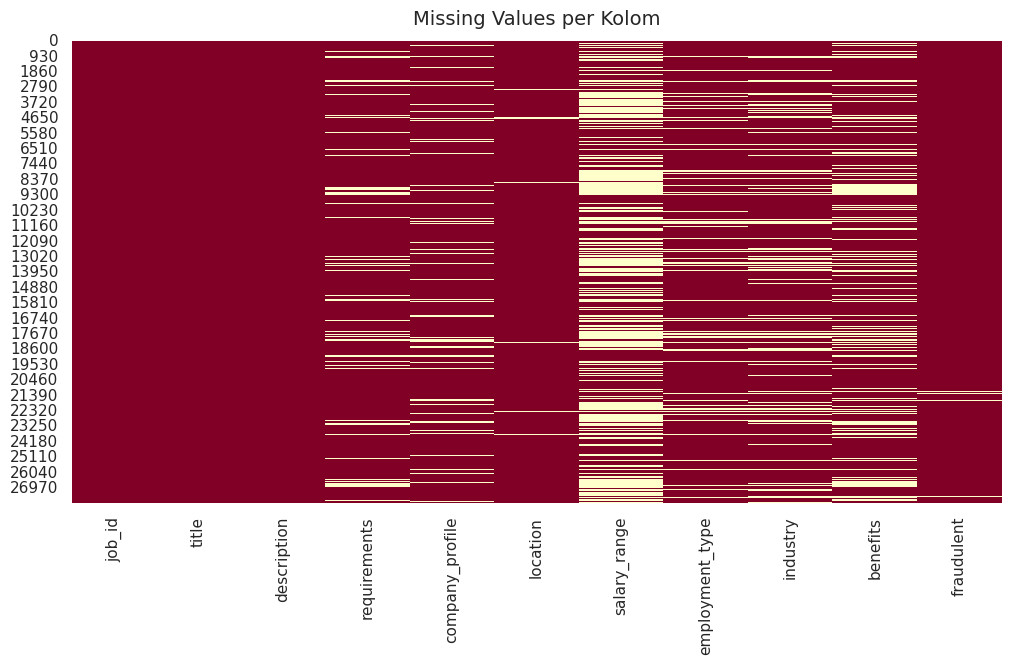

In [ ]:
missing_spark = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_pdf = missing_spark.toPandas().T
missing_pdf.columns = ["Jumlah Missing"]
missing_pdf["Persentase (%)"] = (missing_pdf["Jumlah Missing"] / df.count() * 100).round(2)
missing_pdf = missing_pdf.sort_values("Jumlah Missing", ascending=False)
display(missing_pdf)

# Heatmap
pdf = df.toPandas()
plt.figure(figsize=(12,6))
sns.heatmap(pdf.isnull(), cbar=False, cmap="YlOrRd_r")
plt.title("Missing Values per Kolom")
plt.show()

,fraudulent,Jumlah,Persentase (%)
0,0,16012,59.65
1,1,10832,40.35


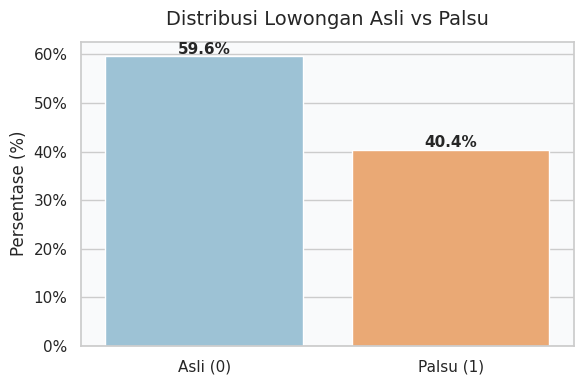

In [ ]:
df = df.withColumn("fraudulent", col("fraudulent").cast("int"))
df = df.filter(col("fraudulent").isin(0,1))

fraud_pdf = (
    df.groupBy("fraudulent")
      .agg(count("*").alias("Jumlah"))
      .orderBy("fraudulent")
      .toPandas()
)

fraud_pdf["Persentase (%)"] = (fraud_pdf["Jumlah"] / df.count() * 100).round(2)
display(fraud_pdf)

blue = plt.get_cmap('Blues_r')(0.6)
orange = plt.get_cmap('Oranges_r')(0.6)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Asli (0)", "Palsu (1)"],
    y=fraud_pdf["Persentase (%)"],
    palette=[blue, orange]
)

plt.title("Distribusi Lowongan Asli vs Palsu")
plt.ylabel("Persentase (%)")
plt.xlabel("")
plt.gca().yaxis.set_major_formatter(PercentFormatter())

for i, v in enumerate(fraud_pdf["Persentase (%)"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

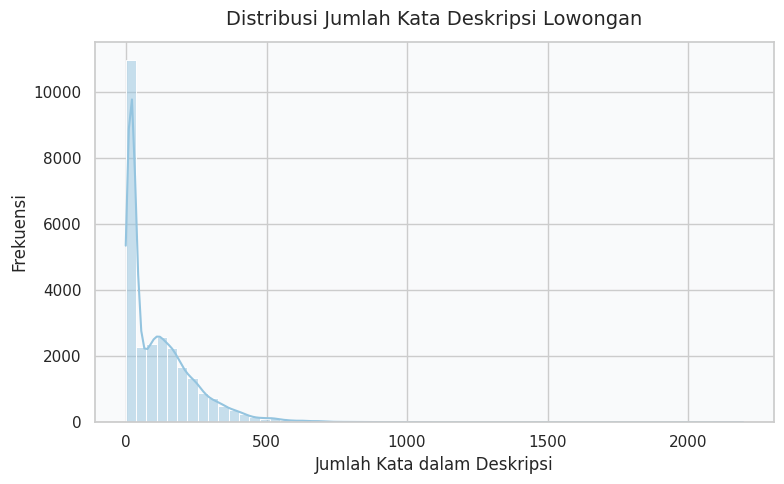

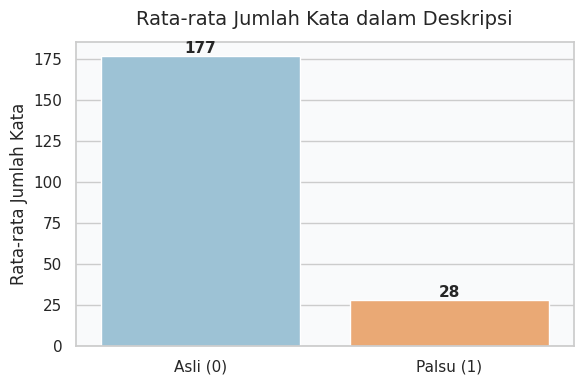

In [ ]:
# Hitung jumlah kata pada kolom description
df = df.withColumn(
    "desc_word_count",
    size(
        split(
            trim(
                regexp_replace(
                    col("description").cast("string"),
                    "[^A-Za-z0-9 ]",
                    " "
                )
            ),
            r"\s+"
        )
    )
)

# Memastikan kolom fraudulent hanya 0/1
df = df.withColumn("fraudulent", col("fraudulent").cast("int"))
df = df.filter(col("fraudulent").isin(0, 1))

# Convert ke Pandas untuk plotting
pdf = df.select("desc_word_count", "fraudulent").toPandas()

# Warna
blue = plt.get_cmap('Blues_r')(0.6)
orange = plt.get_cmap('Oranges_r')(0.6)

# Histogram Distribusi Word Count
plt.figure(figsize=(8, 5))
sns.histplot(pdf["desc_word_count"], bins=60, kde=True, color=blue)
plt.title("Distribusi Jumlah Kata Deskripsi Lowongan")
plt.xlabel("Jumlah Kata dalam Deskripsi")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Rata-rata Word Count
avg_word_pdf = (
    df.groupBy("fraudulent")
      .agg(avg("desc_word_count").alias("avg_words"))
      .orderBy("fraudulent")
      .toPandas()
)

avg_word_values = avg_word_pdf["avg_words"].round(1).values

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Asli (0)", "Palsu (1)"],
    y=avg_word_values,
    palette=[blue, orange]
)
plt.title("Rata-rata Jumlah Kata dalam Deskripsi")
plt.ylabel("Rata-rata Jumlah Kata")

for i, v in enumerate(avg_word_values):
    ax.text(i, v + 2, f"{v:.0f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

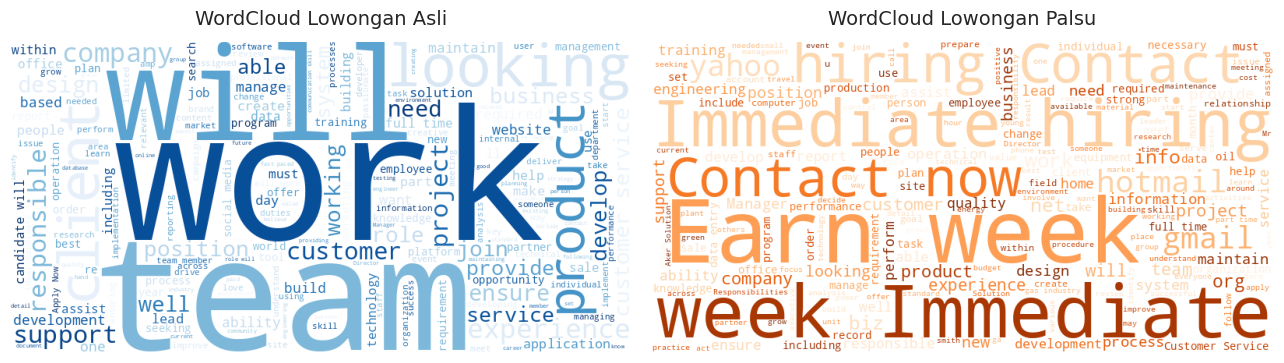

In [ ]:
df = df.withColumn("fraudulent", col("fraudulent").cast("int"))
df = df.filter(col("fraudulent").isin(0, 1))

fake_text = (
    df.filter(col("fraudulent") == 1)
      .select("description")
      .na.drop()
      .toPandas()["description"]
      .astype(str)
      .str.cat(sep=" ")
)

if len(fake_text.strip()) == 0:
    fake_text = "fake"

real_text = (
    df.filter(col("fraudulent") == 0)
      .select("description")
      .na.drop()
      .toPandas()["description"]
      .astype(str)
      .str.cat(sep=" ")
)

if len(real_text.strip()) == 0:
    real_text = "real"

plt.figure(figsize=(13, 6))

# WordCloud Lowongan Asli
plt.subplot(1, 2, 1)
plt.imshow(
    WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Blues_r",
        max_words=200
    ).generate(real_text)
)
plt.axis("off")
plt.title("WordCloud Lowongan Asli")

# WordCloud Lowongan Palsu
plt.subplot(1, 2, 2)
plt.imshow(
    WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Oranges_r",
        max_words=200
    ).generate(fake_text)
)
plt.axis("off")
plt.title("WordCloud Lowongan Palsu")

plt.tight_layout()
plt.show()

In [ ]:
df_visualization = df[
    (df["location"] != "Unknown") &
    (df["industry"] != "Unknown") &
    (df["employment_type"] != "Unknown") &
    (df["title"] != "Unknown")
]

df_real = df_visualization[df_visualization["fraudulent"] == 0]
df_fraud = df_visualization[df_visualization["fraudulent"] == 1]

/tmp/ipython-input-2636461923.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


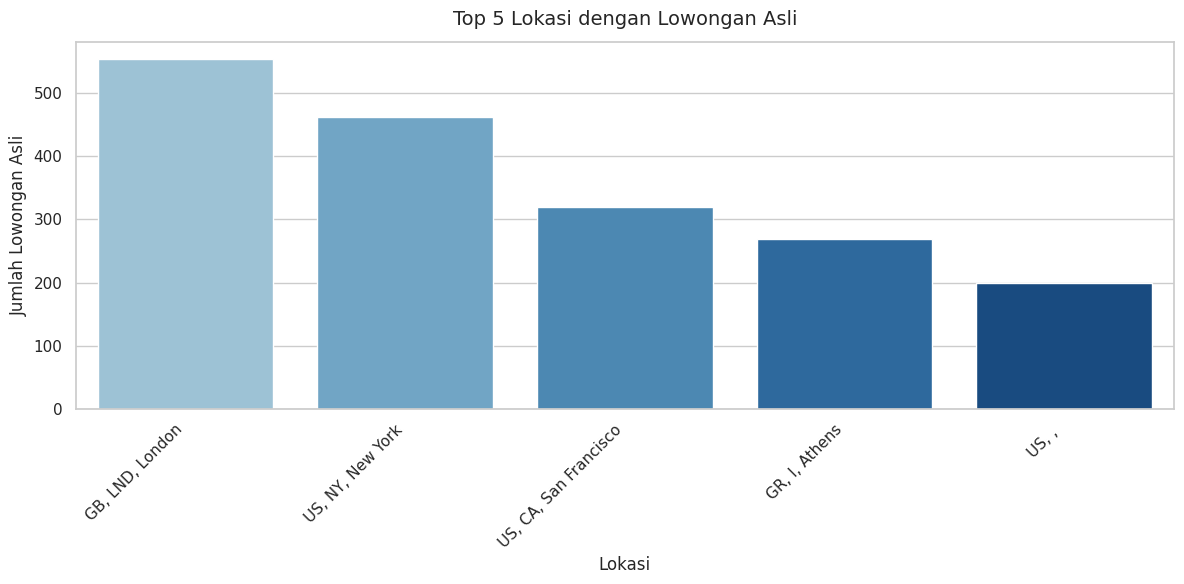

In [ ]:
sns.set_theme(style="whitegrid")

df_real_pd = df_real.toPandas()

cmap_blue = plt.get_cmap("Blues")
colors_5_blue = cmap_blue(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

loc_real = (
    df_real_pd.groupby("location")
              .size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
              .head(5)
)

sns.barplot(
    data=loc_real,
    x="location",
    y="count",
    palette=colors_5_blue,
    order=loc_real["location"]
)

plt.title("Top 5 Lokasi dengan Lowongan Asli", fontsize=14)
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Lowongan Asli")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1393609788.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


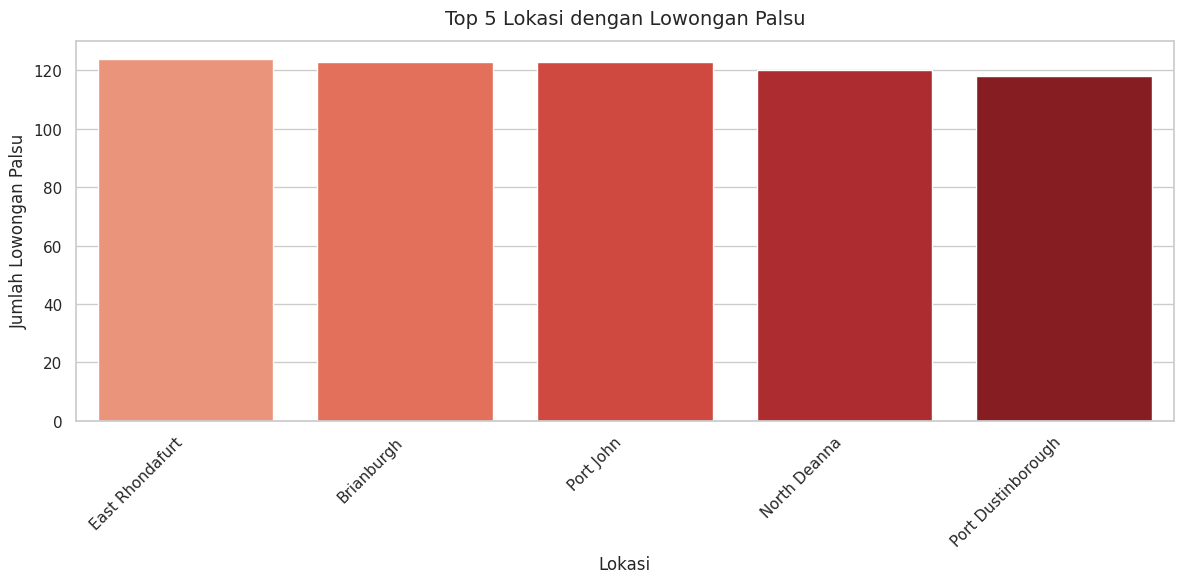

In [ ]:
sns.set_theme(style="whitegrid")

df_fraud_pd = df_fraud.toPandas()

cmap = plt.get_cmap("Reds")
colors_5 = cmap(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

loc_fraud = (
    df_fraud_pd.groupby("location")
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False)
               .head(5)
)

sns.barplot(
    data=loc_fraud,
    x="location",
    y="count",
    palette=colors_5,
    order=loc_fraud["location"]
)

plt.title("Top 5 Lokasi dengan Lowongan Palsu", fontsize=14)
plt.xlabel("Lokasi")
plt.ylabel("Jumlah Lowongan Palsu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1470863640.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


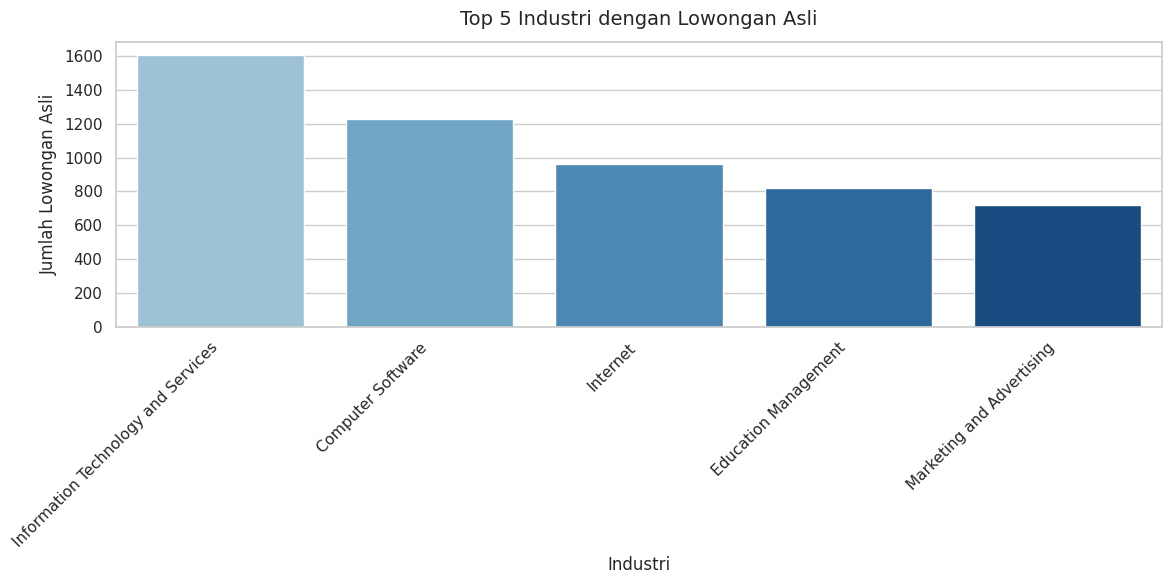

In [ ]:
sns.set_theme(style="whitegrid")

df_real_pd = df_real.toPandas()

cmap_blue = plt.get_cmap("Blues")
colors_5_blue = cmap_blue(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

ind_real = (
    df_real_pd.groupby("industry")
              .size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
              .head(5)
)

sns.barplot(
    data=ind_real,
    x="industry",
    y="count",
    palette=colors_5_blue,
    order=ind_real["industry"]
)

plt.title("Top 5 Industri dengan Lowongan Asli", fontsize=14)
plt.xlabel("Industri")
plt.ylabel("Jumlah Lowongan Asli")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2250452558.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


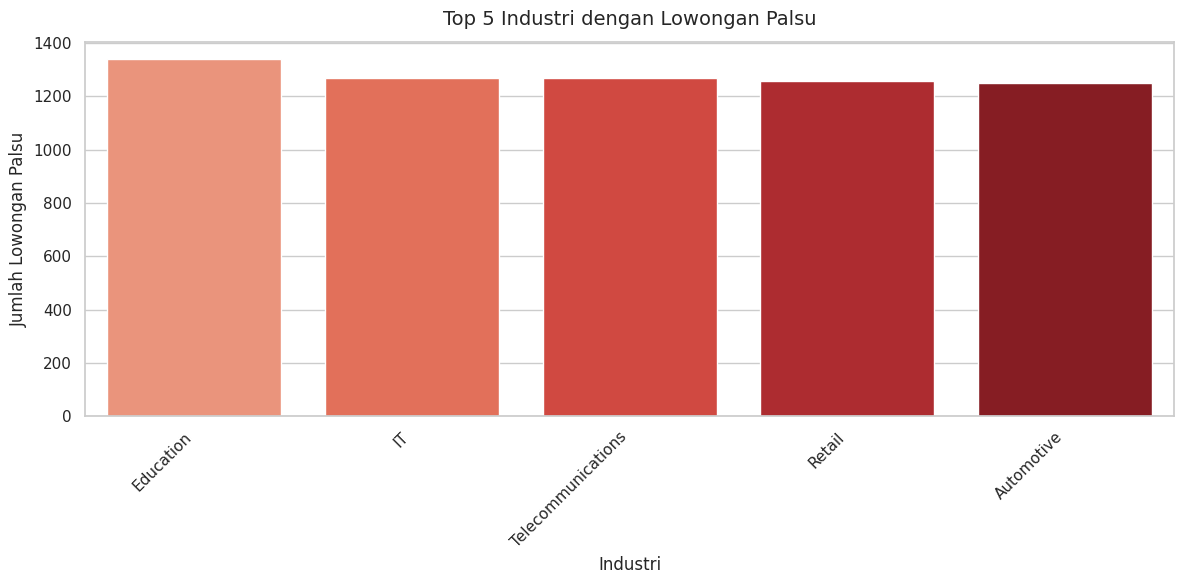

In [ ]:
sns.set_theme(style="whitegrid")

df_fraud_pd = df_fraud.toPandas()

cmap = plt.get_cmap("Reds")
colors_5 = cmap(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

ind_fraud = (
    df_fraud_pd.groupby("industry")
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False)
               .head(5)
)

sns.barplot(
    data=ind_fraud,
    x="industry",
    y="count",
    palette=colors_5,
    order=ind_fraud["industry"]
)

plt.title("Top 5 Industri dengan Lowongan Palsu", fontsize=14)
plt.xlabel("Industri")
plt.ylabel("Jumlah Lowongan Palsu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-4150983579.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


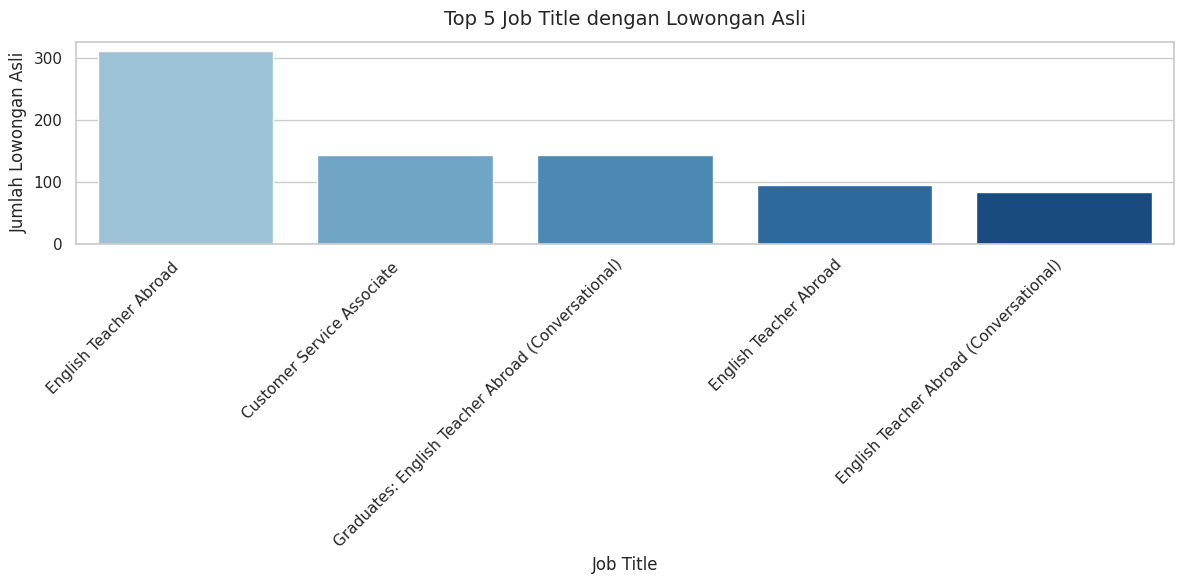

In [ ]:
sns.set_theme(style="whitegrid")

df_real_pd = df_real.toPandas()

cmap_blue = plt.get_cmap("Blues")
colors_5_blue = cmap_blue(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

title_real = (
    df_real_pd.groupby("title")
              .size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
              .head(5)
)

sns.barplot(
    data=title_real,
    x="title",
    y="count",
    palette=colors_5_blue,
    order=title_real["title"]
)

plt.title("Top 5 Job Title dengan Lowongan Asli", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Jumlah Lowongan Asli")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2963056825.py:18: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


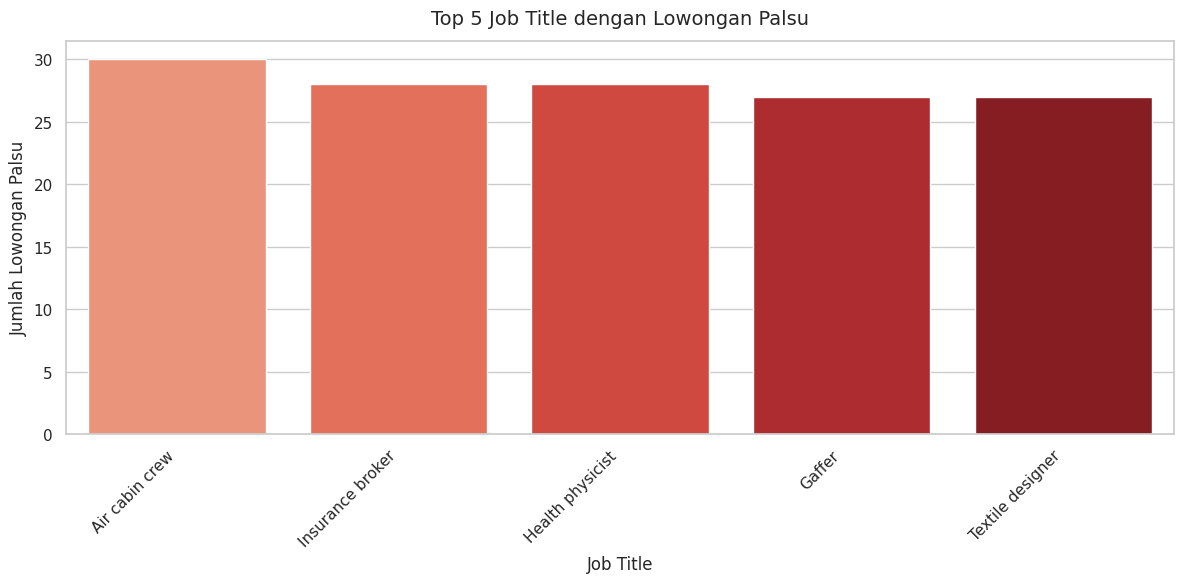

In [ ]:
sns.set_theme(style="whitegrid")

df_fraud_pd = df_fraud.toPandas()

cmap = plt.get_cmap("Reds")
colors_5 = cmap(np.linspace(0.4, 0.9, 5))

plt.figure(figsize=(12, 6))

title_fraud = (
    df_fraud_pd.groupby("title")
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False)
               .head(5)
)

sns.barplot(
    data=title_fraud,
    x="title",
    y="count",
    palette=colors_5,
    order=title_fraud["title"]
)

plt.title("Top 5 Job Title dengan Lowongan Palsu", fontsize=14)
plt.xlabel("Job Title")
plt.ylabel("Jumlah Lowongan Palsu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

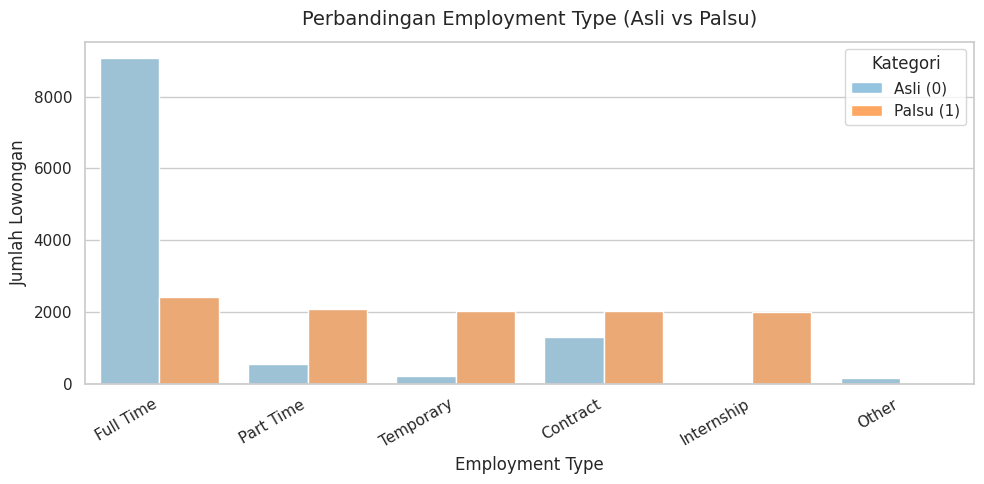

In [ ]:
# Normalisasi employment_type
df = df.withColumn(
    "employment_type_clean",
    initcap(
        trim(
            regexp_replace(
                lower(col("employment_type")),
                r"[-_]", " "
            )
        )
    )
)

# Membuat df_visualization
df_visualization = df[
    (df["location"] != "Unknown") &
    (df["industry"] != "Unknown") &
    (df["employment_type_clean"] != "Unknown") &
    (df["title"] != "Unknown")
]

# Dipakai untuk Pandas
df_emp_type_pd = (
    df_visualization
    .withColumn("employment_type", col("employment_type_clean"))
    .toPandas()
)

sns.set_theme(style="whitegrid")
colors = [blue, orange]

plt.figure(figsize=(10, 5))

emp_count = (
    df_emp_type_pd.groupby(["employment_type", "fraudulent"])
             .size()
             .reset_index(name="count")
             .sort_values("count", ascending=False)
)

sns.barplot(
    data=emp_count,
    x="employment_type",
    y="count",
    hue="fraudulent",
    palette=colors
)

plt.title("Perbandingan Employment Type (Asli vs Palsu)", fontsize=14)
plt.xlabel("Employment Type")
plt.ylabel("Jumlah Lowongan")
plt.xticks(rotation=30, ha="right")

legend_elements = [
    Patch(facecolor=blue, label="Asli (0)"),
    Patch(facecolor=orange, label="Palsu (1)")
]

plt.legend(handles=legend_elements, title="Kategori")
plt.tight_layout()
plt.show()

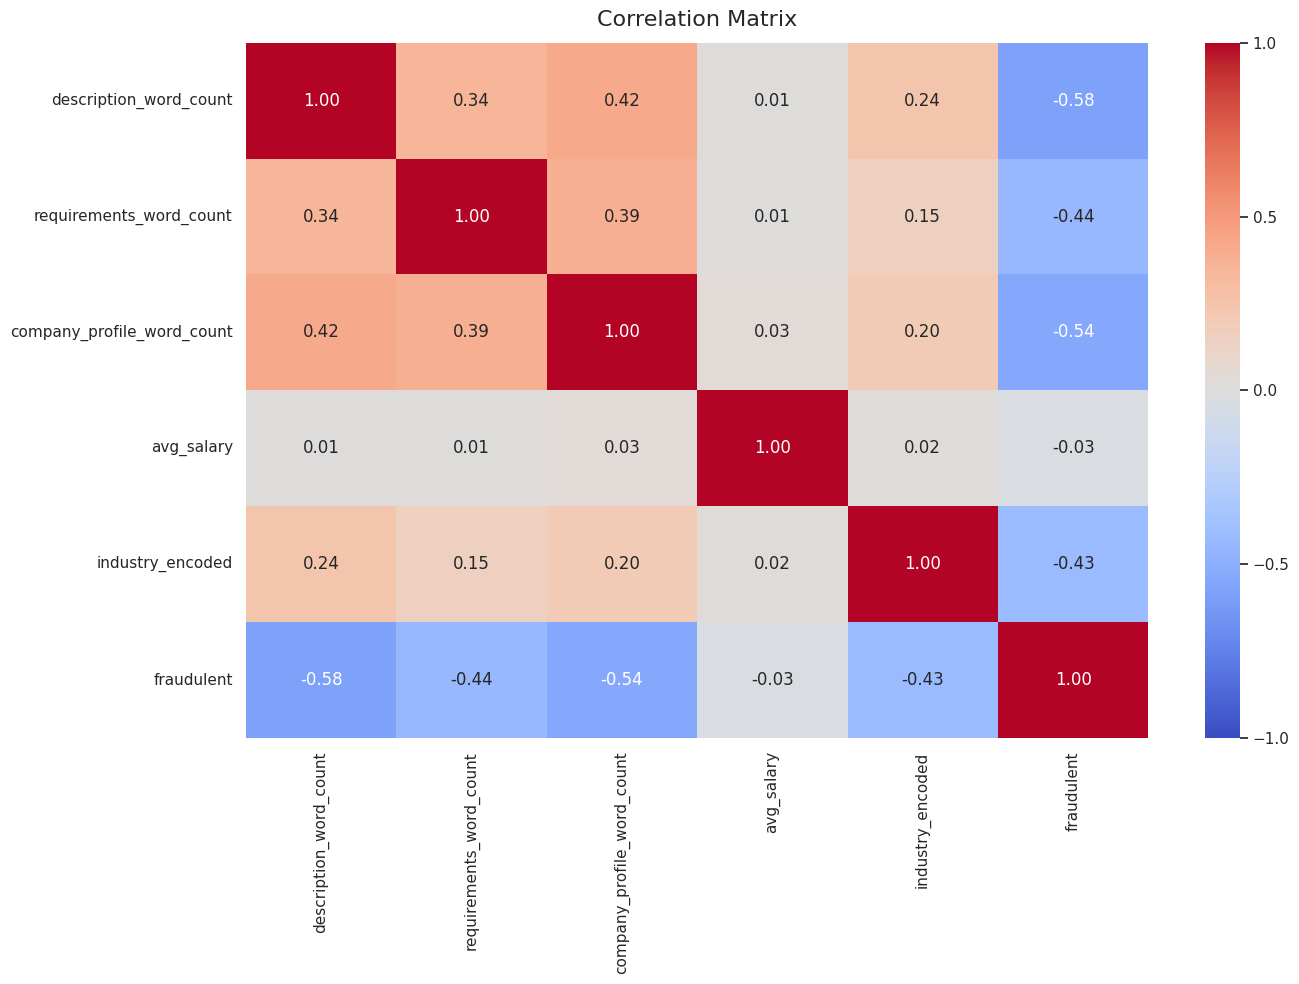

In [ ]:
# Menghitung jumlah kata untuk setiap kolom teks
text_columns = [
    "description",
    "requirements",
    "company_profile"
]

for c in text_columns:
    df = df.withColumn(
        f"{c}_word_count",
        F.size(
            F.split(
                F.coalesce(F.col(c).cast("string"), F.lit("")),
                r"\s+"  # Split berdasarkan spasi (regex)
            )
        )
    )

# Membersihkan salary_range agar hanya berisi angka dan tanda "-"
df = df.withColumn(
    "salary_clean",
    F.regexp_replace(
        F.coalesce(F.col("salary_range").cast("string"), F.lit("")),
        r"[^0-9\-]",
        ""
    )
)

# Extract nilai minimum gaji
df = df.withColumn(
    "min_salary",
    F.regexp_extract(F.col("salary_clean"), r"^(\d+)", 1).cast("double")
)

# Extract nilai maksimum gaji
df = df.withColumn(
    "max_salary",
    F.regexp_extract(F.col("salary_clean"), r"(\d+)$", 1).cast("double")
)

# Menghitung rata-rata gaji sebagai representasi tunggal fitur gaji
df = df.withColumn(
    "avg_salary",
    F.when(
        F.col("min_salary").isNotNull() & F.col("max_salary").isNotNull(),
        (F.col("min_salary") + F.col("max_salary")) / 2
    )
)

# Menghapus fitur salary yang redundant
df = df.drop("min_salary", "max_salary", "salary_clean")

# Encoding kolom industry menjadi numerik
index_cols = ["industry"]

for c in index_cols:
    indexer = StringIndexer(
        inputCol=c,
        outputCol=f"{c}_encoded",
        handleInvalid="keep"  # Menangani kategori baru atau null
    )
    df = indexer.fit(df).transform(df)

# Memastikan label fraudulent bertipe integer (0 = asli, 1 = palsu)
df = df.withColumn(
    "fraudulent",
    F.col("fraudulent").cast("int")
)

# Memilih fitur numerik yang akan dianalisis korelasinya
selected_numeric_cols = [
    "description_word_count",
    "requirements_word_count",
    "company_profile_word_count",
    "avg_salary",
    "industry_encoded",
    "fraudulent"
]

# Konversi ke Pandas untuk menghitung korelasi
df_corr_pd = (
    df.select(selected_numeric_cols)
      .toPandas()
      .dropna(axis=1, how="all")  # Menghapus kolom yang seluruhnya kosong
)

# Menghitung matriks korelasi
corr_matrix = df_corr_pd.corr()

# Visualisasi korelasi
ticks = np.linspace(-1, 1, 5)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,    # Menampilkan nilai korelasi
    fmt=".2f",
    cbar_kws={"ticks": ticks}
)

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

### DATA PREPROCESSING

In [ ]:
import re
import nltk
import hashlib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

Pembersihan data selesai.
Mulai membersihkan teks deskripsi...
Spark DataFrame 'df_cleaned' berhasil dibuat.


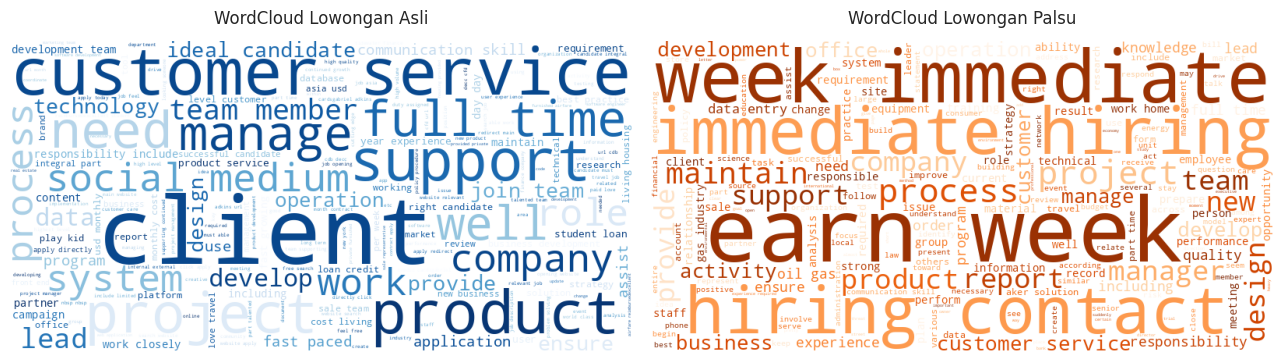

In [ ]:
from pyspark.sql.functions import (
    monotonically_increasing_id,
    row_number,
    col,
    when,
    lit
)
from pyspark.sql.window import Window

window_spec = Window.orderBy(monotonically_increasing_id())
df_indexed = df.withColumn("temp_id", row_number().over(window_spec) - 1)

df_pd = df_indexed.toPandas()

df_pd["description"] = df_pd["description"].fillna("no_description_provided")

fill_cols = [
    "requirements",
    "company_profile",
    "location",
    "salary_range",
    "employment_type",
    "industry",
    "benefits"
]
df_pd[fill_cols] = df_pd[fill_cols].fillna("Unknown")

print("Pembersihan data selesai.")

# Text cleaning
def clean_and_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\bamp\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    clean_tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return " ".join(clean_tokens)

print("Mulai membersihkan teks deskripsi...")
df_pd["clean_description"] = df_pd["description"].apply(clean_and_lemmatize)

temp_path = "/tmp/clean_description.csv"

df_pd[["temp_id", "clean_description"]].to_csv(
    temp_path,
    index=False
)

spark_clean_desc_df = spark.read.csv(
    temp_path,
    header=True,
    inferSchema=True
)

df_cleaned = (
    df_indexed
    .join(spark_clean_desc_df, on="temp_id", how="left")
    .drop("temp_id")
)

print("Spark DataFrame 'df_cleaned' berhasil dibuat.")

# WordCloud
fake_clean = " ".join(
    df_pd.loc[df_pd["fraudulent"] == 1, "clean_description"].dropna()
)
real_clean = " ".join(
    df_pd.loc[df_pd["fraudulent"] == 0, "clean_description"].dropna()
)

if not fake_clean.strip():
    fake_clean = "no_fake_data_found"
if not real_clean.strip():
    real_clean = "no_real_data_found"

plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.imshow(
    WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="Blues_r",
        random_state=42
    ).generate(real_clean)
)
plt.axis("off")
plt.title("WordCloud Lowongan Asli")

plt.subplot(1, 2, 2)
plt.imshow(
    WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="Oranges_r",
        random_state=42
    ).generate(fake_clean)
)
plt.axis("off")
plt.title("WordCloud Lowongan Palsu")

plt.tight_layout()
plt.show()

### MODEL

In [ ]:
from sklearn.model_selection import train_test_split
from pyspark.sql.functions import monotonically_increasing_id

df_with_id = df_cleaned.withColumn(
    "row_id",
    monotonically_increasing_id()
)

label_pd = df_with_id.select("row_id", "fraudulent").toPandas()

X_dummy = label_pd["row_id"].to_numpy().reshape(-1, 1)
y = label_pd["fraudulent"].to_numpy()

# Stratified split
train_ids, test_ids = train_test_split(
    X_dummy,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_ids = [int(x) for x in train_ids.flatten().tolist()]
test_ids  = [int(x) for x in test_ids.flatten().tolist()]

train_data = df_with_id.filter(col("row_id").isin(train_ids))
test_data  = df_with_id.filter(col("row_id").isin(test_ids))

train_data = train_data.drop("row_id")
test_data  = test_data.drop("row_id")

print("=== STRATIFIED TRAIN / TEST SPLIT ===")

print("\nDistribusi Train:")
train_data.groupBy("fraudulent").count().show()

print("\nDistribusi Test:")
test_data.groupBy("fraudulent").count().show()

print("Total Train:", train_data.count())
print("Total Test :", test_data.count())

=== STRATIFIED TRAIN / TEST SPLIT ===

Distribusi Train:
+----------+-----+
|fraudulent|count|
+----------+-----+
|         1| 8666|
|         0|12809|
+----------+-----+


Distribusi Test:
+----------+-----+
|fraudulent|count|
+----------+-----+
|         1| 2166|
|         0| 3203|
+----------+-----+

Total Train: 21475
Total Test : 5369


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, GBTClassifier, NaiveBayes
from pyspark.ml.feature import (
    Tokenizer,
    HashingTF,
    IDF,
    VectorAssembler
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator

for c in ["clean_description"]:
    train_data = train_data.withColumn(
        c, when(col(c).isNull(), lit("")).otherwise(col(c))
    )
    test_data = test_data.withColumn(
        c, when(col(c).isNull(), lit("")).otherwise(col(c))
    )

# Numeric features
numeric_cols = [
    "description_word_count",
    "requirements_word_count",
    "company_profile_word_count",
    "industry_encoded"
]

for c in numeric_cols:
    train_data = train_data.withColumn(
        c, when(col(c).isNull(), lit(0)).otherwise(col(c))
    )
    test_data = test_data.withColumn(
        c, when(col(c).isNull(), lit(0)).otherwise(col(c))
    )

# Distribusi data
print(f"{' DATASET DISTRIBUTION SUMMARY ':^60}")
print("=" * 60)

for name, data in [("Training", train_data), ("Testing", test_data)]:
    total = data.count()
    fake  = data.filter("fraudulent = 1").count()
    real  = total - fake
    print(f"{name:<10} | Total: {total:<6} | Real: {real:<6} | Fake: {fake:<6}")

print("=" * 60 + "\n")

# Pipeline
tokenizer = Tokenizer(
    inputCol="clean_description",
    outputCol="words"
)

tf = HashingTF(
    inputCol="words",
    outputCol="tf",
    numFeatures=2000
)

idf = IDF(
    inputCol="tf",
    outputCol="text_features"
)

assembler = VectorAssembler(
    inputCols=[
        "text_features",
        "description_word_count",
        "requirements_word_count",
        "company_profile_word_count",
        "industry_encoded"
    ],
    outputCol="features",
    handleInvalid="keep"
)

# Evaluasi
def evaluate_model(pred, model_name):
    evaluator = BinaryClassificationEvaluator(
        labelCol="fraudulent",
        metricName="areaUnderROC"
    )
    auc = evaluator.evaluate(pred)

    tp = pred.filter("prediction = 1 AND fraudulent = 1").count()
    tn = pred.filter("prediction = 0 AND fraudulent = 0").count()
    fp = pred.filter("prediction = 1 AND fraudulent = 0").count()
    fn = pred.filter("prediction = 0 AND fraudulent = 1").count()

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0

    fake_precision = tp / (tp + fp) if (tp + fp) else 0
    fake_recall    = tp / (tp + fn) if (tp + fn) else 0
    fake_f1        = (
        2 * fake_precision * fake_recall / (fake_precision + fake_recall)
        if (fake_precision + fake_recall) else 0
    )

    real_precision = tn / (tn + fn) if (tn + fn) else 0
    real_recall    = tn / (tn + fp) if (tn + fp) else 0
    real_f1        = (
        2 * real_precision * real_recall / (real_precision + real_recall)
        if (real_precision + real_recall) else 0
    )

    print(f"\n=== {model_name.upper()} PERFORMANCE ===")
    print(f"Accuracy (Overall): {accuracy:.4f}")
    print(f"ROC-AUC           : {auc:.4f}")
    print("-" * 45)
    print("Class REAL (0):")
    print(f"Precision: {real_precision:.4f}")
    print(f"Recall   : {real_recall:.4f}")
    print(f"F1-Score : {real_f1:.4f}")
    print("-" * 45)
    print("Class FAKE (1):")
    print(f"Precision: {fake_precision:.4f}")
    print(f"Recall   : {fake_recall:.4f}")
    print(f"F1-Score : {fake_f1:.4f}")
    print("-" * 45)
    print("Confusion Matrix:")
    print(f"TN={tn}  FP={fp}")
    print(f"FN={fn}  TP={tp}")
    print("=" * 45)

# Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="fraudulent",
    maxIter=30
)

lr_pipeline = Pipeline(stages=[
    tokenizer,
    tf,
    idf,
    assembler,
    lr
])

print("Training Logistic Regression...")
lr_model = lr_pipeline.fit(train_data)
lr_pred  = lr_model.transform(test_data)

evaluate_model(lr_pred, "Logistic Regression")

# GBT Classifier
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="fraudulent",
    maxIter=50,
    maxDepth=5
)

gbt_pipeline = Pipeline(stages=[
    tokenizer,
    tf,
    idf,
    assembler,
    gbt
])

print("\nTraining GBT Classifier...")
gbt_model = gbt_pipeline.fit(train_data)
gbt_pred  = gbt_model.transform(test_data)

evaluate_model(gbt_pred, "GBT Classifier")

# Naive Bayes
nb = NaiveBayes(
    featuresCol="features",
    labelCol="fraudulent",
    modelType="multinomial"
)

nb_pipeline = Pipeline(stages=[
    tokenizer,
    tf,
    idf,
    assembler,
    nb
])

print("\nTraining Naive Bayes Classifier...")
nb_model = nb_pipeline.fit(train_data)
nb_pred  = nb_model.transform(test_data)

evaluate_model(nb_pred, "Naive Bayes")

                DATASET DISTRIBUTION SUMMARY                
Training   | Total: 21475  | Real: 12809  | Fake: 8666  
Testing    | Total: 5369   | Real: 3203   | Fake: 2166  

Training Logistic Regression...

=== LOGISTIC REGRESSION PERFORMANCE ===
Accuracy (Overall): 0.8364
ROC-AUC           : 0.8720
---------------------------------------------
Class REAL (0):
Precision: 0.8575
Recall   : 0.8647
F1-Score : 0.8611
---------------------------------------------
Class FAKE (1):
Precision: 0.8057
Recall   : 0.7962
F1-Score : 0.8009
---------------------------------------------
Confusion Matrix:
TN=1342  FP=210
FN=223  TP=871

Training GBT Classifier...

=== GBT CLASSIFIER PERFORMANCE ===
Accuracy (Overall): 0.9675
ROC-AUC           : 0.9868
---------------------------------------------
Class REAL (0):
Precision: 0.9553
Recall   : 0.9910
F1-Score : 0.9728
---------------------------------------------
Class FAKE (1):
Precision: 0.9865
Recall   : 0.9342
F1-Score : 0.9596
--------------------

### Testing

In [ ]:
if "job_id" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn(
        "job_id", monotonically_increasing_id()
    )

# Text feature
df_cleaned = df_cleaned.withColumn(
    "clean_description",
    when(col("clean_description").isNull(), lit(""))
    .otherwise(col("clean_description"))
)

# Numeric features yang dipakai model
numeric_cols = [
    "description_word_count",
    "requirements_word_count",
    "company_profile_word_count",
    "industry_encoded"
]

for c in numeric_cols:
    df_cleaned = df_cleaned.withColumn(
        c, when(col(c).isNull(), lit(0)).otherwise(col(c))
    )

# Menggunakan GBT
prediction_result = gbt_model.transform(df_cleaned).select(
    "job_id",
    "fraudulent",
    "prediction",
    "probability"
)

def check_job_prediction(job_id):
    result = (
        prediction_result
        .filter(col("job_id") == job_id)
        .collect()
    )

    if not result:
        print(f"[ERROR] Job ID {job_id} tidak ditemukan.")
        return

    row = result[0]

    # Label asli
    actual_label = "FAKE" if row["fraudulent"] == 1 else "REAL"

    # Label prediksi
    predicted_label = "FAKE" if row["prediction"] == 1.0 else "REAL"

    prob_real = float(row["probability"][0])
    prob_fake = float(row["probability"][1])

    print("=" * 65)
    print(f"Job ID              : {job_id}")
    print(f"Label Asli          : {actual_label}")
    print(f"Prediksi Model (GBT): {predicted_label}")
    print("-" * 65)
    print(f"Probabilitas REAL   : {prob_real:.4f}")
    print(f"Probabilitas FAKE   : {prob_fake:.4f}")
    print("=" * 65)

# Contoh
check_job_prediction(1)
check_job_prediction(15000)

Job ID              : 1
Label Asli          : FAKE
Prediksi Model (GBT): FAKE
-----------------------------------------------------------------
Probabilitas REAL   : 0.0216
Probabilitas FAKE   : 0.9784
Job ID              : 15000
Label Asli          : REAL
Prediksi Model (GBT): REAL
-----------------------------------------------------------------
Probabilitas REAL   : 0.9450
Probabilitas FAKE   : 0.0550
